![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_1/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  PCA para estudiar la dimensionalidad de la calidad de vida en las ciudades

En este caso-taller vamos a aplicar PCA en el estudio de calidad de vida en diferentes ciudades. Para ello, haremos uso de los datos que surgen del Almanaque Calificado de Lugares. En este Almanaque Boyer y Savageau calificaron 329 ciudades de acuerdo con los siguientes nueve criterios:

   - Clima y Terreno
   - Alojamiento
   - Cuidado de la salud y el medio ambiente
   - Crimen
   - Transporte
   - Educación
   - Artes
   - Recreación
   - Economía

Con tantas variables disponibles, la matriz de dispersión puede resultar muy grande para estudiarla e interpretarla adecuadamente. Habría demasiadas correlaciones bivariadas entre las variables a considerar. Para interpretar los datos de una forma más significativa es necesario reducir el número de variables a unas pocas dimensiones, y para ello en este ejercicio recurriremos al análisis de componentes principales.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo junto al archivo de soporte.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en la misma ruta de acceso del cuaderno, por ejemplo: `data/archivo_de_soporte.csv`.

## Desarrollo


### 1. Carga de datos

En el repositorio de taller 1 encontraran una carpeta `data` donde se encuentra el archivo `lugares.csv`, cargue estos datos en su *cuaderno*.


In [1]:
# Utilice este espacio para escribir el código.

#### Función para instalar las librerías usadas en la primera parte del Taller 1 (en caso de que no las tenga instaladas)
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada')    

### Lista con el nombre de las librerías usadas en el ejercicio
librerias_taller = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn']

### Loop-for para las librerías
for i in librerias_taller:
    install_load(i)

#### Librerías usadas en la primera parte del Taller 1
import numpy as np                        ##  Computación científica en Python
import pandas as pd                       ##  Manejo y manipulación de datos en Python
import matplotlib.pyplot as plt           ##  Gráficos básicos en Python
import seaborn as sns                     ##  Gráficos estadísticos en Python

from sklearn.decomposition import PCA     ## Funciones para el Análisis de Componentes Principales (PCA)
from sklearn.preprocessing import StandardScaler ## Función para estandarizar las variables numéricas


## Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')                   


#### Cargando el archivo lugares.csv desde el repositorio personal de GitHub

### Guardamos la URL de los datos crudos de lugares en el objeto url_raw
url_raw = 'https://raw.githubusercontent.com/fevidals/Aprendizaje-No-Supervisado/refs/heads/main/data/lugares.csv'

### Leemos el archivo lugares.csv con la librería Pandas
df = pd.read_csv(url_raw)

### Vamos a estandarizar los títulos de las columnas del DataFrame
df.columns = (
    df.columns
    .str.normalize('NFKD')                    ## Separa las letras de las tilder
    .str.encode('ascii', errors = 'ignore')   ## Elimina las tildes sueltas
    .str.decode('utf-8')                      ## Reconstrucción del texto 
    .str.lower()                              ## Convierte las letras mayúsculas a minúsculas
    .str.replace(' ', '_')                    ## Reemplaza los espacios por un guion al piso
)

### Aplicamos un head para examinar las cinco primeras filas de DataFrame
df.head()


La librería numpy ya está instalada
La librería pandas ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería sklearn ya está instalada


,ciudad,clima_y_terreno,alojamiento,cuidado_de_la_salud_y_el_medio_ambiente,crimen,transporte,educacion,artes,recreacion,economia
0,"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
1,"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
2,"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
3,"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
4,"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


(Utilice este espacio para describir su procedimiento)

- Paso 1: Creamos la función install_load() para verificar si las librerías usadas están instaladas en el computador local, si no ocurre lo anterior las librerías son instaladas mediante -pip. Posteriormente, importamos las librerías que vamos a utilizar en el taller de PCA. En la parte derecha está una corta descripción de cada una de ellas.

- Paso 2: para poder cargar automáticamente la base de datos, en formato csv, guardamos la URL de los datos crudos en
texto plano, desde el respositorio personal de GitHub (fevidals), en el objeto url_raw.

- Paso 3: con la función read_csv(), de la librería Pandas, cargamos la base de datos y la guardamos en un objeto
DataFrame bautizado como df. Posteriormente. Finalmente, convertimos los títulos (strings) del DataFrame a un nuevo texto sin tildes, espacios y mayúsculas. Posteriormente, aplicamos un head() al df para ver las cinco primeras filas.

- Paso 4: Finalmente, convertimos los títulos (strings) del DataFrame a un nuevo texto sin tildes, espacios y mayúsculas.

### 2.  Análisis descriptivo de las variables.

Para el análisis descriptivo haga uso de estadísticas descriptivas y matrices de correlación. Indique además cuantas gráficas de dispersión bivariadas debería examinar con este número de variables.

Explique porqué es importante conocer las estadísticas descriptivas y como contribuyen al ejercicio posterior de Análisis de Componentes Principales.

Tenga en cuenta que para las variables, a excepción de la alojamiento y crimen, cuanto mayor sea el puntaje, mejor. Por el contrario; para alojamiento y crimen, mientras más bajo sea el puntaje, mejor. También, mientras algunas comunidades podrían calificar mejor en las artes, otras podrían calificar mejor en otras áreas como tener una tasa de criminalidad más baja y buenas oportunidades educativas.

Tabla de Estadísticas Descriptivas:


,N,NaNs,Media,Mediana,SD,SE,L_I_95%,L_S_95%
clima_y_terreno,329.0,0,538.7,542.0,120.8,6.7,525.7,551.8
alojamiento,329.0,0,8346.6,7877.0,2385.3,131.5,8088.8,8604.3
cuidado_de_la_salud_y_el_medio_ambiente,329.0,0,1185.7,833.0,1003.0,55.3,1077.4,1294.1
crimen,329.0,0,961.1,947.0,357.2,19.7,922.5,999.6
transporte,329.0,0,4210.1,4080.0,1451.2,80.0,4053.3,4366.9
educacion,329.0,0,2814.9,2794.0,320.8,17.7,2780.2,2849.6
artes,329.0,0,3150.9,1871.0,4642.3,255.9,2649.2,3652.5
recreacion,329.0,0,1846.0,1670.0,807.9,44.5,1758.7,1933.3
economia,329.0,0,5525.4,5384.0,1084.5,59.8,5408.2,5642.6


Matriz de Correlación entre las Variables de Calidad de Vida:


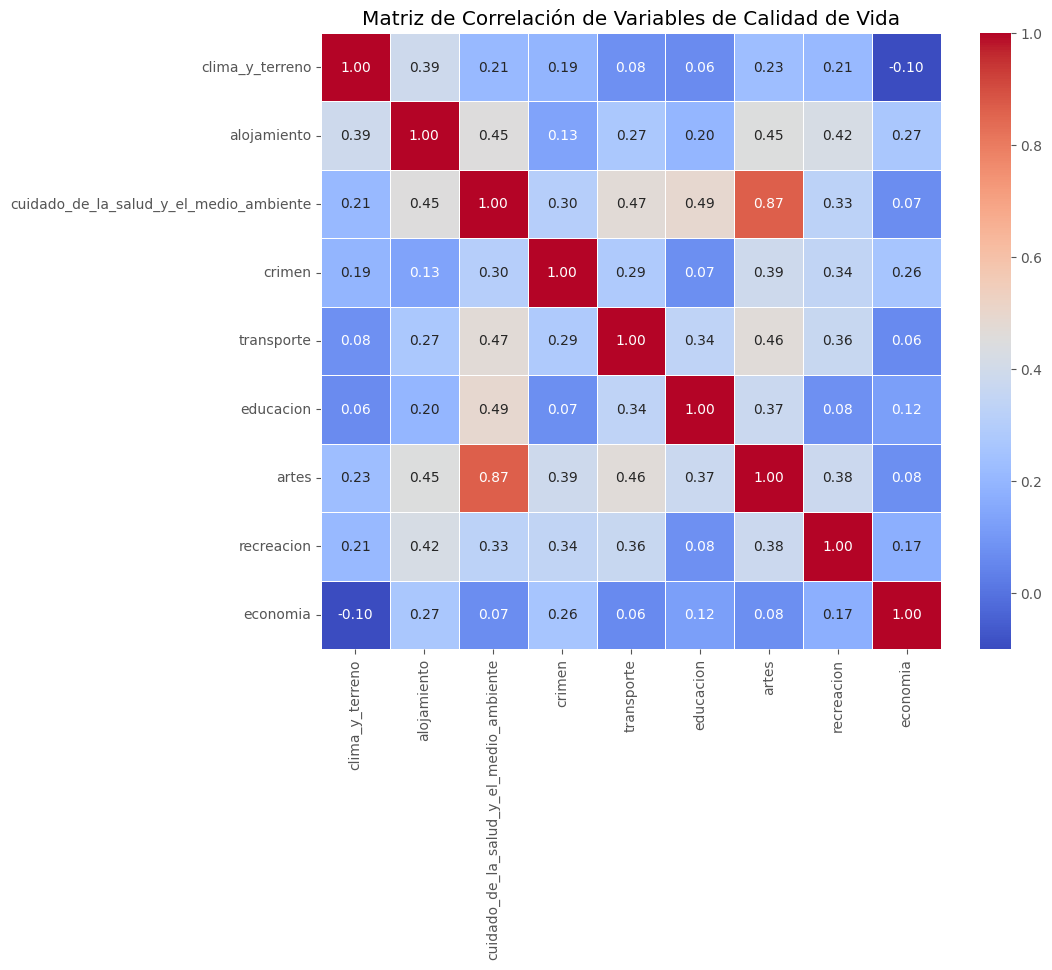

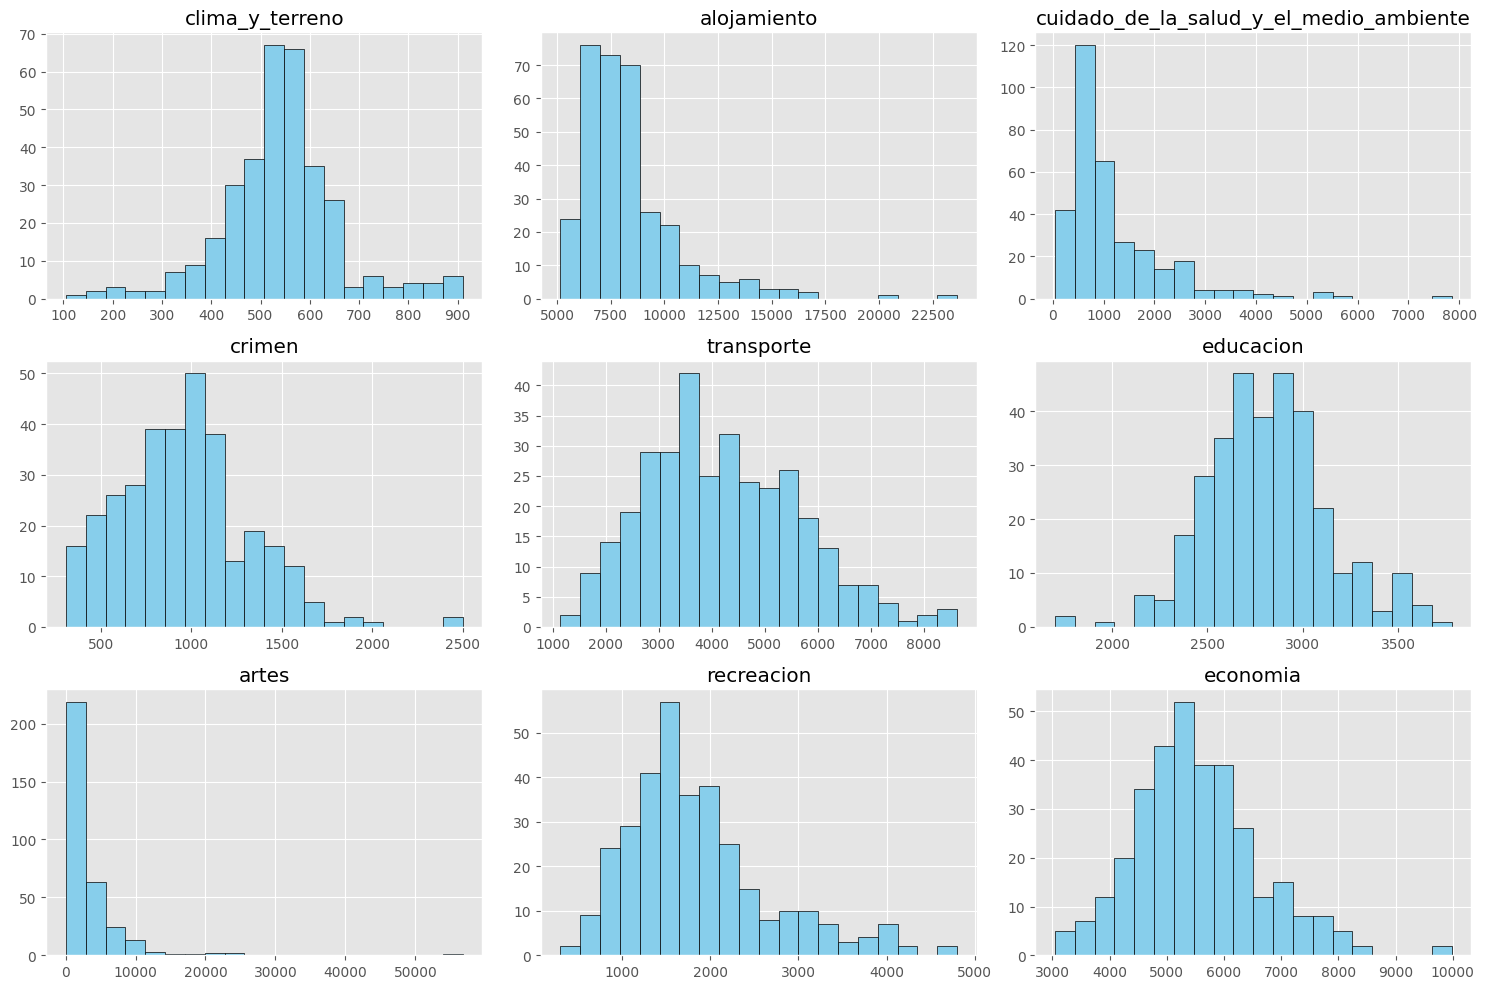

In [2]:
# Utilice este espacio para escribir el código.

##### Estadísticas descriptivas del DataFrame

### 1. Separamos las variables numéricas del DataFrame en el objeto df_num
df_num = df.select_dtypes(include = 'number')

### 2. Calculando las estadísticas descriptivas básicas del objeto df_num
resumen_tab = df_num.describe().T

### 3. Añadimos una columna que contiene el número de datos vacíos (NaNs) en cada variable 
resumen_tab['NaNs'] = df_num.isna().sum()

### 4. Modificamos el título de las variables en la tabla descriptiva

resumen_tab = resumen_tab.rename(columns = {
    'count': 'N',
    'mean': 'Media',
    'std': 'SD',
    '50%': 'Mediana'  # <-- Rescatamos la mediana aquí
})

### 5. Calculando el Error Estándar (SE)
resumen_tab['SE'] = resumen_tab['SD'] / np.sqrt(resumen_tab['N'])

### 6. Calculando los Intervalos de Confianza al 95%
resumen_tab['L_I_95%'] = resumen_tab['Media'] - 1.96 * resumen_tab['SE']
resumen_tab['L_S_95%'] = resumen_tab['Media'] + 1.96 * resumen_tab['SE']

### 7. Filtramos y elegimos el orden exacto de nuestras columnas
tabla_descrip = resumen_tab[['N', 'NaNs', 'Media', 'Mediana', 'SD', 'SE', 'L_I_95%', 'L_S_95%']]

## Mostrar la tabla descriptiva con los valores redondeados a un decimal
print("Tabla de Estadísticas Descriptivas:")
display(tabla_descrip.round(1))

##### Tabla de correlaciones entre las variables numéricas del DataFrame

### 1. Calculamos la matriz de correlaciones mediante el objeto matriz_corr
matriz_corr = df_num.corr()

### 2. Usamos las librerías Matplotlib y Seaborn para graficar la matriz de correlación
print("Matriz de Correlación entre las Variables de Calidad de Vida:")
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables de Calidad de Vida')
plt.show()

#Histogramas de las variables de medición  ----------------------------------------
df_num.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

In [3]:
#### (Pendiente) Adicionar las gráficas de histogramas

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

- Tabla de estadísticas descriptivas: en la tabla que contiene las estadísticas descriptivas básicas podemos ver que todas las variables numéricas tienen las mismas observaciones (329 filas) y no hay presencia de datos faltantes (NaNs), por lo que no hay que realizar algún método de imputación de datos en nuestro análisis. En algunas variables (i.e. artes o cuidado de la salud y medio ambiente), la media es mucho más grande que la mediana, lo que muestra una asimetría positiva elevada generada por algunas ciudades que tienen puntajes muy elevados. Además, hay una gran diferencia entre los puntajes de variables como crimen vs alojamiento, esto nos indica que será necesario hacer una estandarización de todas las variables numéricas para llevar a cabo un PCA. 


- Gráfico de correlación: la matriz de correlación presenta varios índices cercanos a cero, representados en color azul claro, con la excepción de artes y cuidad de la salud que tiene un coeficiente de 0,87. Los coeficientes cercanos a cero muestran que algunas variables son linealmente independientes entre sí y pueden dificultar la implementación del PCA porque el algorítmo no podrá reducir la dimensión, devolviendo componentes principales idénticos a las variables originales, pero sí podrá reducir las variables con elevada correlación.

- Número de gráficas: si quisiéramos hacer una gráfica de dispersión para comparar cada una de las variables numéricas, tendríamos que implementar 36 gráficas de dispersión bivariadas para hacer un análisis gráficos de la posible correlación entre las variables.


#### 2.3 Conclusiones:

1. Distribución y correlación dimensiones de interés: 
    * **Artes, Alojamiento y Cuidado de la salud y el medio ambiente**: Estas dimensiones tienes distribuciones aproxidamente chi2. Esto indica que hay un grupo relativamente pequeño de ciudades que se comporta diferente a las demás en estos aspectos. Revisando la matriz de correlación se puede evidenciar que estas dimensiones se correlacionan positivamente entre sí y que tienes correlaciones superiores a la media. Esto ahora nos indica que el grupo de ciudades atípicas son similares en estas dimensiones de interés. 

    * **Clima y Terreno, Crimen, Transporte, Educación, Recreación, Economía**: Estas dimensiones tienen distribuciones que se asemejan a una distribución normal. Esto indica que en promedio las ciudades se comportan de forma más similar para estas variables. Revisando la matriz de correlación y teniendo en cuenta que en promedio las correlaciones no superan el 0.4 podemos ver otras relaciones interesantes. 
        * **Cuidado de la salud y el medio ambiente, Transporte y Educación** Tienen correlaciones positivas superiores a la media. Esto nos da indicios de un ciclo virtuoso donde ciudades con buenos puntajes en algunas amenidades tienen a tener buenos puntajes en otras amenedidades. Esto podría darse porque las pobliciones de estas ciudades tienen mayor demanda por amenidades y capacidad para acceder a ellas. 
    * **Clima y terreno, Crímen y Economía** Son dimensiones que no muestran fuertes correalciones con las otras. Esto apunta preliminarmente a que el crimen y la situación económica impactan de forma más heterogenea las ciudades. 

    > Parace algunas ciudades tienen poblaciones que demandan ciertas amenidades y que fenomenos como el crímen y la situación económica son más heterogeneos. 

2. ¿Cómo conocer mejor los datos ayuda al análisis de los componenetes? 
    * **Entender mejor el contexto** Hacer las estadísticas descriptivas y explorar las datos nos permiten entender mejor el contexto y identificar si los datos están listo para aplicar PCA. Por ejemplo, en este caso identificamos que estamos comparando ciudades en torno a amenidades y que los datos no están normalizados. 
    * **Interpretación de los componenetes** En este caso enteder que estamos hablando de amenidades nos ayuda a empezar a interpretar las correlaciones como amenidades complementarias o amenidades que ciertas poblaciones demandan conjuntamente. Por ejemplo, si al hacer PCA vemos que las variables de Recreación y Medio ambiente tiene loadings relevantes este componente nos habla sobre las preferencia de las poblaciones de ciertas ciudades por tener buenos espacios para divertirse.
    > Esto no ayuda pulir la intuición y empezar a hacer un story telling

### 3.  Cálculo y selección de componentes principales.

Utilizando Álgebra Lineal, calcule los eigen valores y los eigen vectores, a partir de ellos obtenga los Componentes Principales. Tenga en cuenta de estandarizar las variables y explicar por qué es importante no omitir este paso.

Luego, examine los valores propios para determinar cuántos componentes principales se deben considerar. Explique el criterio que utilizó para la elección y justifique su respuesta.

Eigenvalores ordenados:
[3.41868293 1.21767731 1.14495927 0.9237255  0.75558148 0.63248434
 0.49455091 0.31900812 0.12076916]


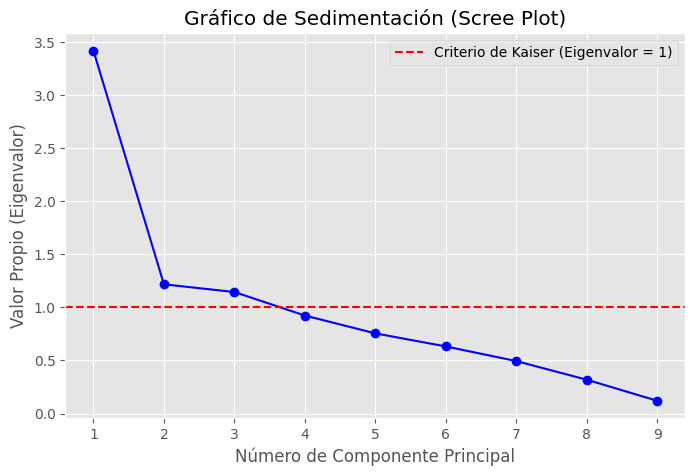

In [4]:
# Utilice este espacio para escribir el código.

### 1. Estandarización de variables numéricas del DataFrame
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_num)

### 2. Calculando la matriz de covarianza para las variables estandarizadas
matriz_corr = np.cov(X_scaled, rowvar = False)

### 3. Calculando los eigenvalores y eigenvectores
eigenvalores, eigenvectores = np.linalg.eig(matriz_corr)

### 4. Ordenamos los eigenvalores de mayor a menor para examinar la varianza explicada

# Con argsort() obtenemos las posiciones de los eigenvalores del menor al mayor y [::-1] permite revertir el orden de mayor a menor  
indices_ordenados = np.argsort(eigenvalores)[::-1]

# Ordenamos los eigenvalores
eigenvalores = eigenvalores[indices_ordenados] 

# Los eigenvectores nos da las direcciones de los componentes principales
eigenvectores = eigenvectores[:, indices_ordenados]

#
print('Eigenvalores ordenados:')
print(eigenvalores)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalores) + 1), eigenvalores, marker='o', linestyle='-', color='b')
plt.axhline(y=1, color='r', linestyle='--', label='Criterio de Kaiser (Eigenvalor = 1)')
plt.title('Gráfico de Sedimentación (Scree Plot)')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Valor Propio (Eigenvalor)')
plt.legend()
plt.xticks(range(1, len(eigenvalores) + 1))
plt.show()

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones).

- 1. Estandarización: en primer lugar debemos volver homogeneas las variables de la base de datos. Esto implica que las nuevas variables
estandarizadas quedan con media igual a cero y desviación estándar de 1. Esto se hace para que el PCA pueda encontrar las direcciones que capturen la mayor varianza de los datos y los resultados no sean distorsionados por las variables que tienen mayores puntajes. Para realizar este procedimiento usamos la librería sklearn con la función StandardScaler().

- 2. Matriz de covarianza: Después calculamos, con las variables estandarizadas, la matriz de covarianza que nos permite ver como están relacionadas entre sí todas las variables estudiadas. Esto lo hacemos al transponer la matriz original con las variables numéricas ($X$) y multiplicarla por esta matriz y el fraccionario de $\frac{1}{n-1}$. Al final tendremos $C = \frac{1}{n-1} X^{T}X$, donde $C$ es la matriz de covarianza de tamaño 9x9.

- 3. Los Eingenvalores (valores propios) e Eingenvectores (vectores propios) se calculan mediante la librería Numpy, obtenemos y ordenamos las posiciones de los eigenvalores, para posteriormente poder obtener los valores ordenados y también los vectores.

- 4. Criterio de Kaiser: el tener las nueve variables estandarizadas implica que cada una aporta una unidad de varianza al sistema y el eigenvalor representa cuanta varianza total captura cada componente. Por lo tanto, si un componente tiene un eigenvalor mayor a 1, significa que captura más varianza. Este criterio propone retener los componentes mayores a uno y que en este ejercicio corresponden a los componentes 1, 2 y 3.

### 4.  Interpretación de los componentes principales.

Logró reducir la dimensión en el ejercicio anterior? Si lo hizo, pueden los pesos obtenidos identificar dimensiones menores de los datos? Provea una interpretación a estas dimensiones, para ello puede utilizar gráficas y/o tablas.

Tabla de los pesos de los tres componentes principales


,PC1,PC2,PC3
clima_y_terreno,0.21,0.22,0.69
alojamiento,0.36,0.25,0.21
cuidado_de_la_salud_y_el_medio_ambiente,0.46,-0.30,0.01
crimen,0.28,0.36,-0.19
transporte,0.35,-0.18,-0.15
educacion,0.28,-0.48,-0.23
artes,0.46,-0.19,0.03
recreacion,0.33,0.38,0.05
economia,0.14,0.47,-0.61


Gráfico de los pesos de las variables en PCA


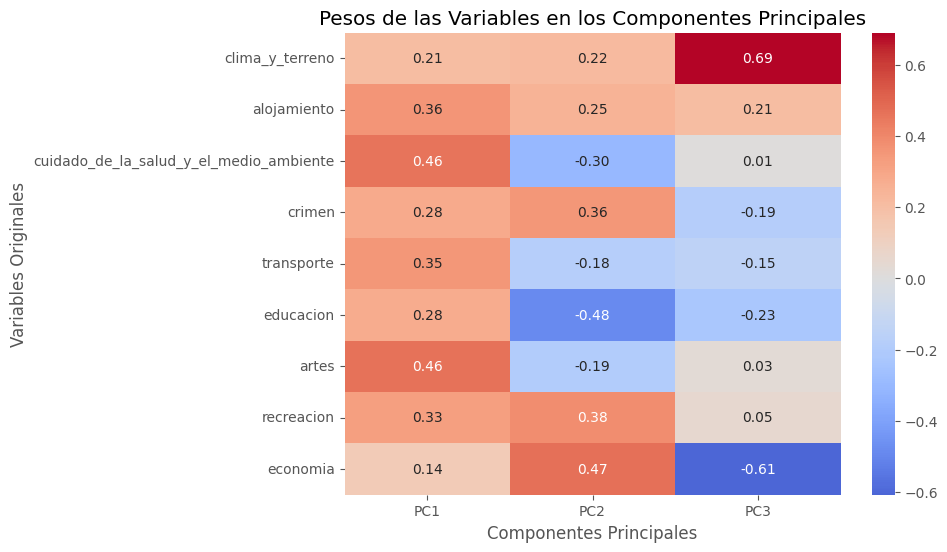

In [5]:
# Utilice este espacio para escribir el código.

### 1. Seleccionamos los primeros tres eingenvectores 
pca_weights = eigenvectores[:, :3]

### 2. Obtenemos los títulos de las variables numéricas
variable_names = df_num.select_dtypes(include = 'number').columns

### 3. Nuevo DataFrame con los eigenvectores 
df_weights = pd.DataFrame(
    data = pca_weights,
    columns = ['PC1', 'PC2', 'PC3'],
    index = variable_names
)


### 4. DataFrame con los valores redondeados a un decimal
print("Tabla de los pesos de los tres componentes principales")
display(df_weights.round(2))

### 5. Gráfico de los pesos de las variables en PCA 
print("Gráfico de los pesos de las variables en PCA")
plt.figure(figsize=(8, 6))
sns.heatmap(df_weights, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Pesos de las Variables en los Componentes Principales')
plt.ylabel('Variables Originales')
plt.xlabel('Componentes Principales')
plt.show()

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones).

- 1. Iniciamos con la separación de los tres primeros Eigenvectores, a partir de la matriz de pesos de los componentes principales, posteriormente creamos un objeto (variable_names) que contiene los títulos de las columnas estudiadas.

- 2. Procedemos a construir un nuevo DataFrame (df_weights), que contiene los pesos de los tres primeros componentes, con sus respectivos títulos de variables y componentes.

- 3. Por último, procedemos a graficar la matriz con los pesos de los tres componentes. El primer componente principal (PC1) solo tiene valores positivos en todos los valores, donde Cuidado de la salud (0.46), artes (0.46) y alojamiento (0.36) son lo más altos. El segundo componente principal (PC2) tiene economía (0.47) y recreación (0.38) como los más altos, mientras que educacion (-0.48) y cuidado de la salud (-0.48) son lo más bajos de este componente. El tercer componente principal (PC3) tiene los valores más altos con clima y terreno (0.69) y economía (-0.61).

- 4. Reducción de dimensionalidad: el ejercicio logró reducir la dimensionalidad de los datos, ya que se pasó de tener nueve variables numéricas a tres componentes principales que resumen la mayor parte de la varianza (información) de los datos originales. 

- 5. Interpretación de las dimensiones:

* **Primera dimensión:** La primera dimensión muestra una agrupación de las ciudades con mejores puntajes en: Educación, Cuidado de la salud y del medio ambiente, Artes y Transporte. Esto muestra una correlación entre el nivel de educación de las población y su demanda por artes y ambientes sanos. Esto podría explicarse porque las personas con mayores niveles de educación tienden a tener mayores ingresos, mayores aspiraciones y a la capicidad para demandar bienes como el arte.
> Resumen de la primera dimensión generada por PCA: Ciudades con poblaciones más educadas, que demandan más amenidades

* **Segunda dimensión:** La segunda dimensión muestra una agrupación de las ciudades con mejores puntajes en: Economía, Alojamiento, Crímen y Recreación. Esto muestra una correlación entre la actividad económica, el tamaño de la población y recreación y crímen, que son dimensiones que problamente tienen mayores gracias a la escala de las ciudades. Esto podría explicarse porque ciudades y mayores niveles de actividad económica y grandes poblaciones son un mercado más grandes para alternativas de recreación y criminalidad. Esto también podría mostrar que algunas ciudades tienen mayor actividad en general.
> Resumen de la segunda dimensión generado por PCA: Ciudades más grandes y activas

* **Tercera dimensión**: el último componente tiene dos categorías con peso extremo en Economía (-0.61) y el Clima_y_terreno (0.69), esto puede representar ciudades con un clima agradable para vivir, pero donde es difícil sostenerse económicamente por temas laborales o de costos.  

### 5.   Detección de ciudades inusuales.

A partir de los Componentes Principales identifique las 5 ciudades calidad de vida inusualmente alta. En la distribución de calidad de vida  de la muestra que tan inusuales son? Cuáles son las dimensiones que hacen que estas ciudades tengan esta calidad de vida inusual?

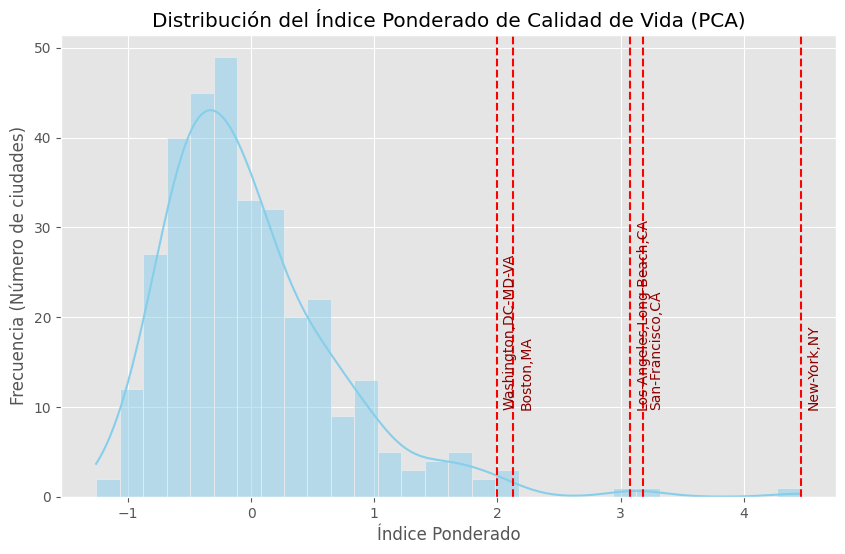

Top 5 de ciudades según el índice ponderado de los tres componentes principales:


,ciudad,PC1,PC2,PC3,indice_ponderado
212,"New-York,NY",12.45,-2.06,0.21,4.46
269,"San-Francisco,CA",7.40,1.23,1.69,3.18
178,"Los-Angeles,Long-Beach,CA",7.26,0.48,2.05,3.07
42,"Boston,MA",6.31,-1.61,-0.36,2.13
313,"Washington,DC-MD-VA",6.20,-2.27,-0.38,1.99


In [ ]:
# Utilice este espacio para escribir el código.

### 1. Multiplicamos la matriz estandarizada previametne (X_scaled) por la matriz de pesos (pca_weights)
puntajes_pca = np.dot(X_scaled, pca_weights)

### 2. Nuevo DataFrame con los puntajes de los componentes principales
df_pca = pd.DataFrame(puntajes_pca, columns=['PC1', 'PC2', 'PC3'])

### 3. Pegamos la columna con el nombre de las ciudad desde el dataframe original
df_pca.insert(0, 'ciudad', df['ciudad'].values)

### 4. Calculamos la varianza de los tres componentes principales
pesos_varianza = eigenvalores[:3] / np.sum(eigenvalores)

### 5. Construímos un índice ponderado de los tres componentes principales
df_pca['indice_ponderado'] = (
    df_pca['PC1'] * pesos_varianza[0] + 
    df_pca['PC2'] * pesos_varianza[1] + 
    df_pca['PC3'] * pesos_varianza[2]
) 

### 6. Extraemos el top 5 de las ciudades 
top_5_ciudades = df_pca.sort_values(by = 'indice_ponderado', 
                                    ascending = False).head(5)

plt.figure(figsize=(10, 6))
sns.histplot(df_pca['indice_ponderado'], bins=30, kde=True, color='skyblue')

### 7. Gráficamos la ubicación de las ciudades del top 5 en el histograma del índice ponderado
for idx, row in top_5_ciudades.iterrows():
    plt.axvline(x=row['indice_ponderado'], color='red', linestyle='--')
    plt.text(row['indice_ponderado']+0.05, 10, row['ciudad'], rotation=90, color='darkred')

plt.title('Distribución del Índice Ponderado de Calidad de Vida (PCA)')
plt.xlabel('Índice Ponderado')
plt.ylabel('Frecuencia (Número de ciudades)')
plt.show()

### 8. Mostramos la tabla con el Top 5 de ciudades según los tres componentes principales
print("Top 5 de ciudades según el índice ponderado de los tres componentes principales:")
display(top_5_ciudades.round(2))

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones).

**- Histograma de distribución:** el histograma del índice ponderado nos muestra que las cinco ciudades seleccionadas por los componentes principales (NYC, San Francisco, Los Ángeles, Boston y Washington DC) son datos muy atípicos en la distribución total de las ciudades, esto es el motivo de estar ubicados en el top 5, ya que sus puntajes de calidad de vida son muy elevados respecto al resto de ciudades y se distancian de la media por varias desviaciones estándar.

- 1. Multiplicación de matrices: el primer paso consiste en multiplicar las matriz numérica por la matriz de pesos previamente calculada y guardamos el resultado en el objeto *puntajes_pca*.

- 2. Creamos un nuevo DataFrame que contiene la matriz del objeto *puntajes_pca* con los títulos de las columnas para cada uno de los tres componentes (PC1, PC2 y PC3). 

- 3. Además, pegamos a este dataframe (*puntajes_pca*) la columna que contiene el nombre de las ciudades y que proviene del dataframe original.

- 4. Calculamos la varianza (información) extrayendo los tres primeros eigenvalores y se divide por la suma de todos estos.

- 5. Índice Ponderado: multiplicamos cada componente principal por los pesos que calculamos en el paso 4, esto nos permite generar un índice para poder hacer un ranking de las ciudades basado en los tres componentes principales que pasaron la prueba del criterio de Kaiser.

- 6. Conclusiones: finalmente calculamos el top 5 de ciudades con los tres componentes principales. Las ciudades son: Nueva York, San Francisco, Los Ángeles, Boston y Washington DC, este grupo es el top cinco de las ciudades que tienen la calidad de vida más alta para sus habitantes:

  - 6.1. Nueva York (NYC): su principal fortaleza está en el PC1, esto demuestra una fuerte oferta cultural (museos, teatros, cinemas), una adecuada sanidad con medio ambiente y un alojamientoa decuado para sus habitales.

  - 6.2. San Francisco: al igual que NYC, acá también tenemos una alpta prevalencia del PC1, sin embargo, acá también tiene un índice positivo el PC2 (una economía fuerte con buena recreación) y el PC3 (un clima muy agradable para los residentes).

  - 6.3. Los Ángeles: es una combinación de una buena oferta cultural, sanidad junto con un clima benigno.

  - 6.4. Boston: similar a NYC, prima el PC1

  - 6.5. Washington DC: similar a NYC, prima el PC1.



De los componentes principales podemos evidenciar que: 

 * **Primera dimensión:** La primera dimensión muestra una agrupación de las ciudades con mejores puntajes en: Educación, Cuidado de la salud y del medio ambiente, Artes y Transporte. Esto muestra una correlación entre el nivel de educación de las población y su demanda por artes y ambientes sanos. Esto podría explicarse porque las personas con mayores niveles de educación tienden a tener mayores ingresos, mayores aspiraciones y a la capicidad para demandar bienes como el arte.
> Resumen de la primera dimensión generada por PCA: Ciudades con poblaciones más educadas, que demandan más amenidades

* **Segunda dimensión:** La segunda dimensión muestra una agrupación de las ciudades con mejores puntajes en: Economía, Alojamiento, Crímen y Recreación. Esto muestra una correlación entre la actividad económica, el tamaño de la población y recreación y crímen, que son dimensiones que problamente tienen mayores gracias a la escala de las ciudades. Esto podría explicarse porque ciudades y mayores niveles de actividad económica y grandes poblaciones son un mercado más grandes para alternativas de recreación y criminalidad. Esto también podría mostrar que algunas ciudades tienen mayor actividad en general.
> Resumen de la segunda dimensión generado por PCA: Ciudades más grandes y activas